<a href="https://colab.research.google.com/github/harshchaudhary11/lab_03_assignment/blob/main/Harsh_Chaudhary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅  TensorFlow 2.19.0 | All libraries loaded

🌱  Training models — ~60s …

  CNN accuracy : 100.0%
  ANN training complete ✅

═════════════════════════════════════════════════════════════════
  🌿  ORCHARD AI  —  LAUNCHING INTERACTIVE FRONTEND
═════════════════════════════════════════════════════════════════



FloatSlider(value=0.7, description='Temperature:', layout=Layout(width='420px'), max=1.0, step=0.01, style=Sli…

FloatSlider(value=0.65, description='Humidity:', layout=Layout(width='420px'), max=1.0, step=0.01, style=Slide…

FloatSlider(value=0.7, description='Soil Moisture:', layout=Layout(width='420px'), max=1.0, step=0.01, style=S…

FloatSlider(value=0.8, description='Days/Bloom:', layout=Layout(width='420px'), max=1.0, step=0.01, style=Slid…

IntSlider(value=30, description='Max frames:', layout=Layout(width='420px'), max=120, min=5, step=5, style=Sli…

IntSlider(value=15, description='Sample every:', layout=Layout(width='420px'), max=60, min=1, style=SliderStyl…

HTML(value='<div style="font-family:monospace;color:#6a9a6a;font-size:11px;padding:8px 0">⬆  Adjust parameters…


✅  UI ready — click IMAGE MODE or VIDEO MODE above!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📷  IMAGE MODE  —  Upload 1 to 5 fruit images
  Accepted: jpg, jpeg, png, webp, bmp
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



Saving WhatsApp Image 2026-04-22 at 10.13.21 (1).jpeg to WhatsApp Image 2026-04-22 at 10.13.21 (1) (3).jpeg
  ✅  Loaded: WhatsApp Image 2026-04-22 at 10.13.21 (1) (3).jpeg  (640×426)

  Image 1/1: WhatsApp Image 2026-04-22 at 10.13.21 (1) (3).jpeg
    🍎  Fruit   : Mango  (97% confidence)
    🌿  Decision: ⏳ WAIT
    🔢  Count   : 5 total | Ripe:0 | Unripe:0 | Damaged:5
    💯  Conf    : 0.0%
    📊  Yield   : 31.3%
    ⏰  Window  : HARVEST NOW

🖼  Rendering summary dashboard …


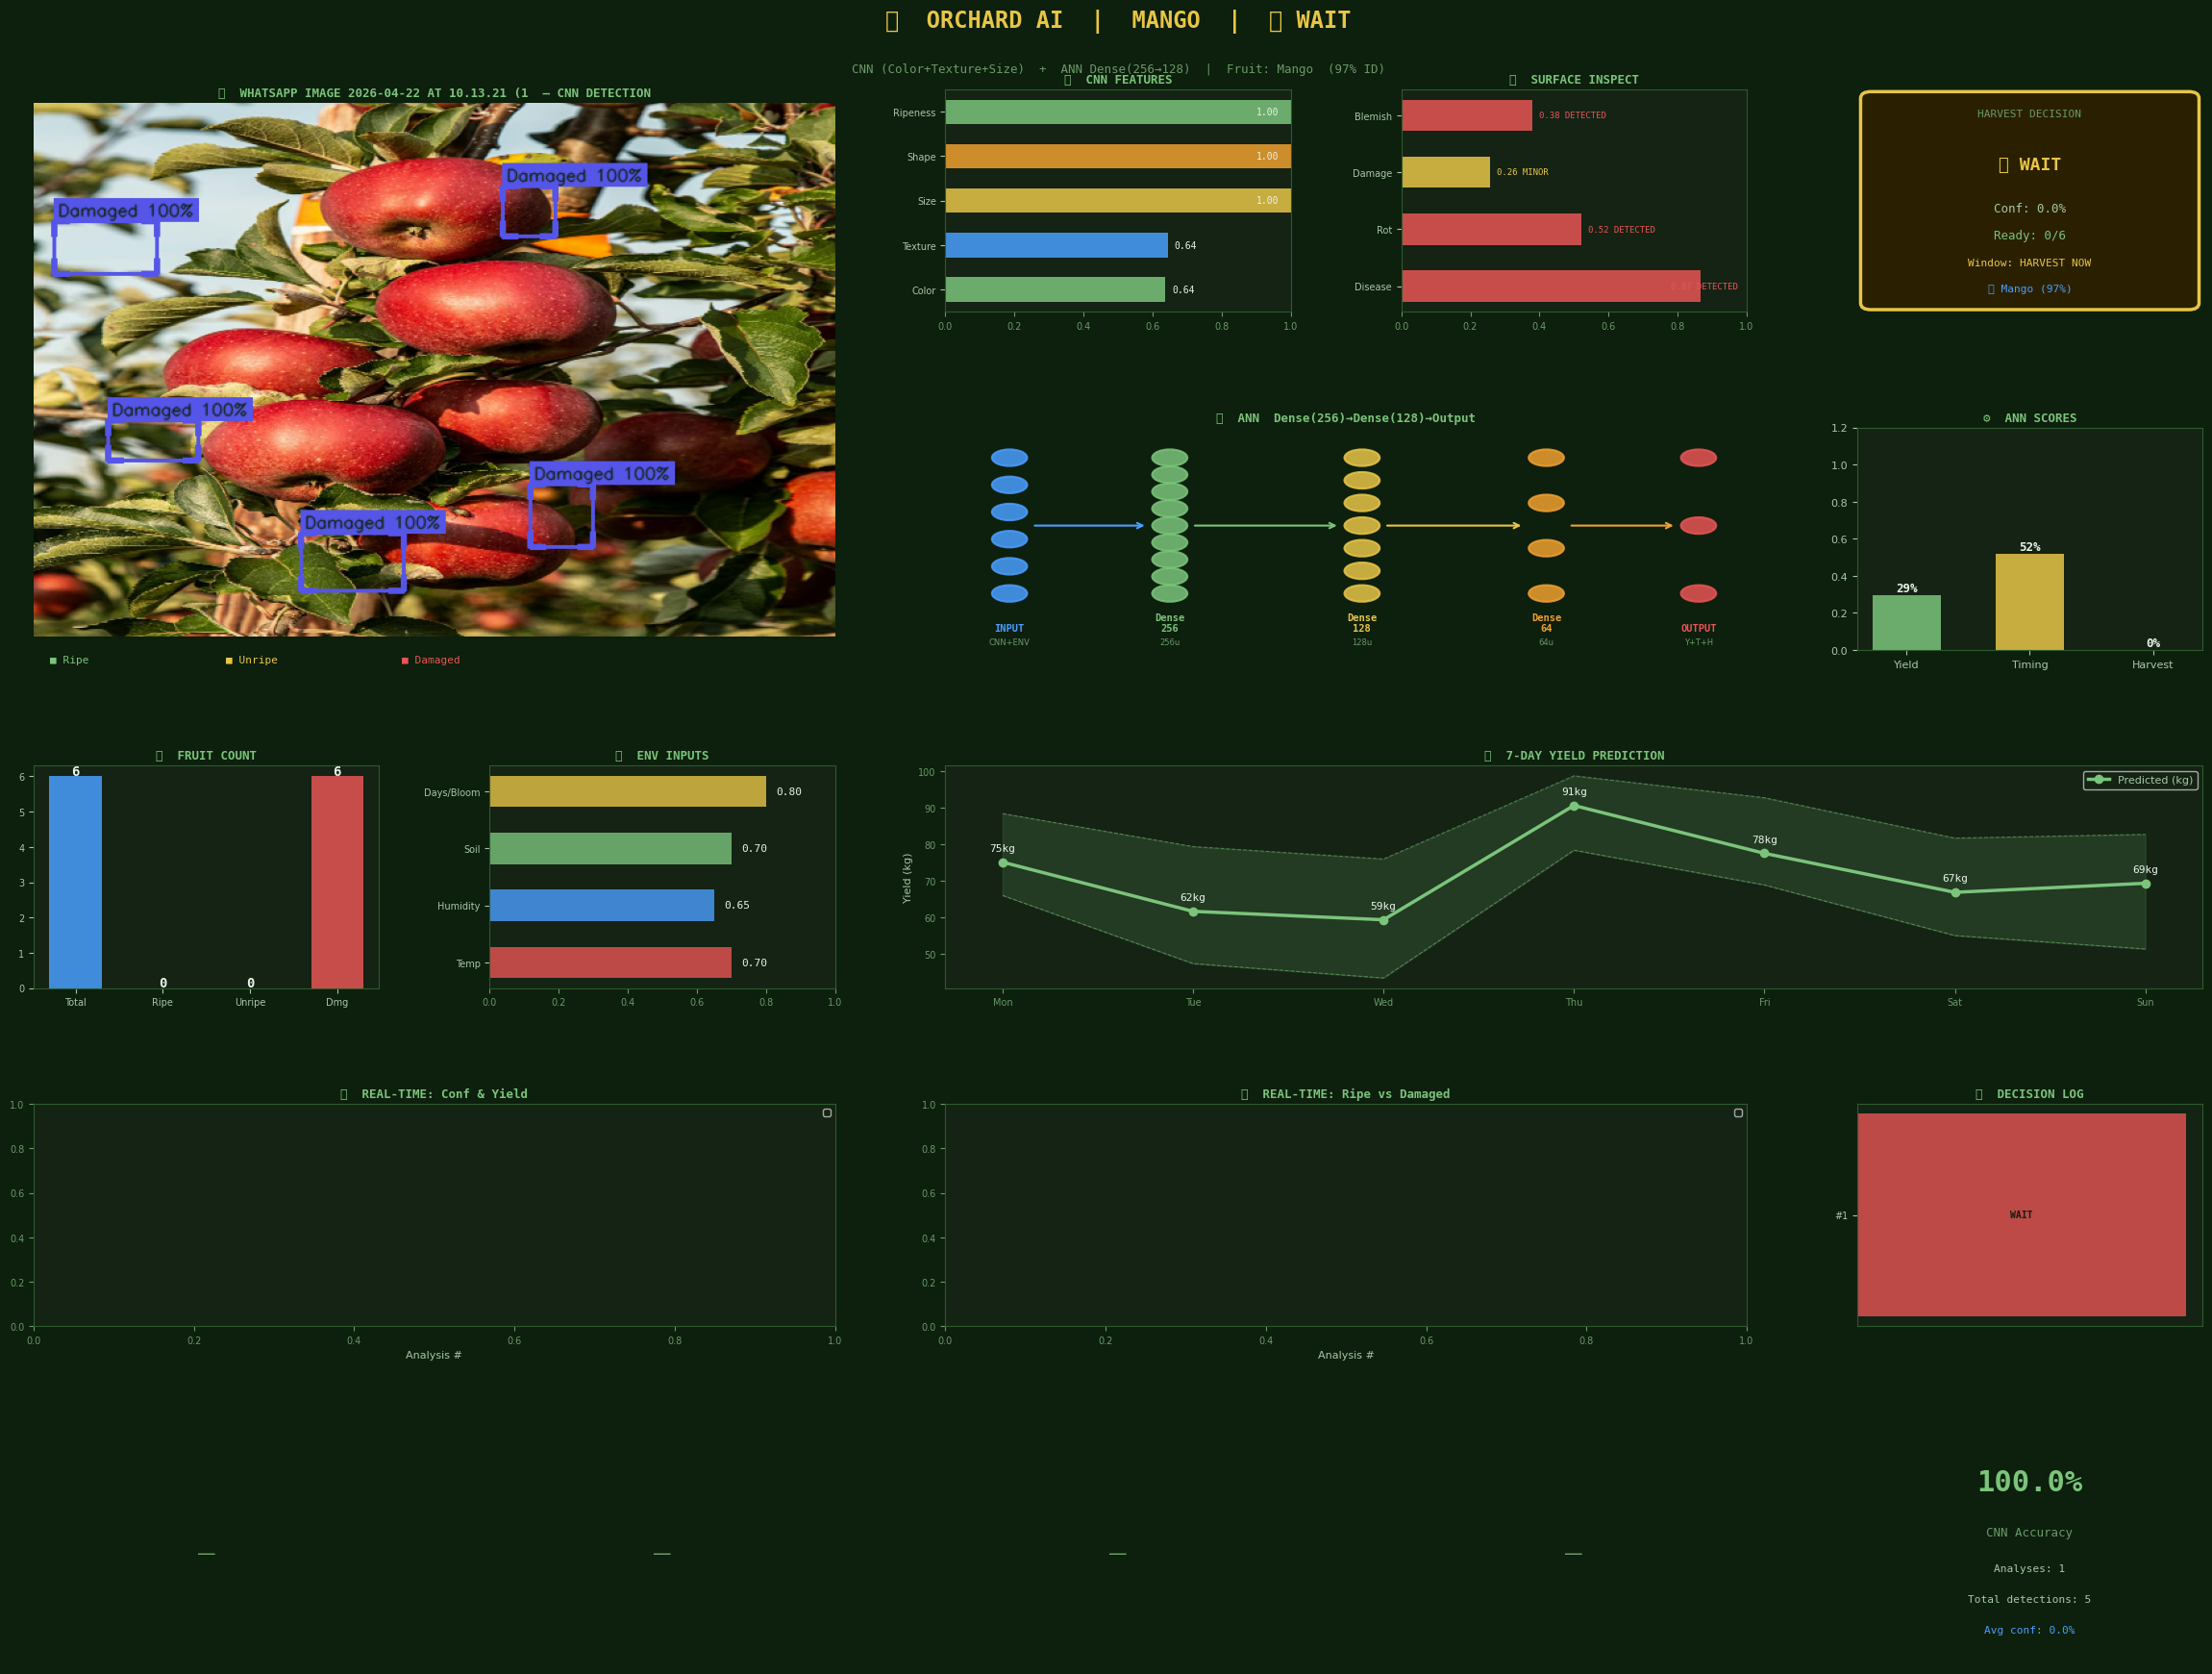

  💾  Dashboard saved → /content/image_dashboard.png

══════════════════════════════════════════════════
  SUMMARY
══════════════════════════════════════════════════
  Overall decision : ⏳ WAIT
  Images analyzed  : 1
  Total fruits     : 5
  Total ripe       : 0
  Avg confidence   : 0.0%
  Avg yield        : 31.3%
══════════════════════════════════════════════════


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2, os, io, time, random, warnings, base64
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from google.colab import files as colab_files

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

BG  = '#0d1f0d'; BG2 = '#142314'; BG3 = '#1e351e'
GRN = '#7bc47b'; AMB = '#e8c547'; RED = '#e85555'
BLU = '#4a9eff'; TXT = '#e8f5e8'; TXT2 = '#a8c8a8'
TXT3 = '#6a9a6a'; GRID = '#2d5a2d'

print("✅  TensorFlow", tf.__version__, "| All libraries loaded")

# CELL 2 ── Fruit Name Identifier


FRUIT_PROFILES = [
    ('Apple',       0,  15,  80, 80, 0.75, 'medium'),
    ('Apple',     160, 180,  80, 80, 0.75, 'medium'),
    ('Orange',     10,  25, 100, 90, 0.80, 'medium'),
    ('Mango',      20,  35,  90, 80, 0.50, 'large'),
    ('Lemon',      25,  40, 100,100, 0.60, 'small'),
    ('Banana',     22,  38,  70, 80, 0.20, 'large'),
    ('Strawberry',  0,  10, 120, 70, 0.55, 'small'),
    ('Cherry',      0,  10, 100, 50, 0.85, 'tiny'),
    ('Grape',     130, 160,  60, 40, 0.88, 'tiny'),
    ('Peach',       5,  20,  80, 90, 0.78, 'medium'),
    ('Plum',      130, 160,  70, 40, 0.80, 'small'),
    ('Watermelon', 60,  90,  80, 50, 0.40, 'large'),
    ('Tomato',      0,  12, 120, 60, 0.82, 'medium'),
    ('Pear',       30,  50,  60, 70, 0.55, 'medium'),
    ('Pineapple',  22,  38,  60, 80, 0.30, 'large'),
    ('Pomegranate', 0,  15, 100, 60, 0.75, 'medium'),
    ('Kiwi',       55,  90,  70, 50, 0.70, 'small'),
    ('Blueberry', 100, 140,  60, 30, 0.90, 'tiny'),
    ('Fig',         0,  20,  50, 40, 0.65, 'small'),
]

def identify_fruit_name(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h_ch = hsv[:,:,0]; s_ch = hsv[:,:,1]; v_ch = hsv[:,:,2]
    mask = (s_ch > 50) & (v_ch > 50)
    if mask.sum() < 100:
        return 'Unknown Fruit', 30.0
    h_vals = h_ch[mask].astype(float)
    s_mean = float(s_ch[mask].mean()); v_mean = float(v_ch[mask].mean())
    angles = h_vals * 2
    dom_hue = int((np.degrees(np.arctan2(
        np.sin(np.radians(angles)).mean(),
        np.cos(np.radians(angles)).mean()
    )) % 360) / 2)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 40, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    roundness = 0.5
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        roundness = min(w, h) / max(max(w, h), 1)
    frac = mask.sum() / mask.size
    size_class = 'large' if frac > 0.35 else 'medium' if frac > 0.15 else 'small'
    scores = {}
    for (name, hlo, hhi, smin, vmin, rmin, sc) in FRUIT_PROFILES:
        hue_match = 1.0 if hlo <= dom_hue <= hhi else max(0, 1 - min(
            abs(dom_hue-hlo), abs(dom_hue-hhi), 180-abs(dom_hue-hlo))/30)
        sat_match  = 1.0 if s_mean >= smin else s_mean/smin
        val_match  = 1.0 if v_mean >= vmin else v_mean/vmin
        round_match = 1.0 if roundness >= rmin else roundness/rmin
        size_match  = 1.0 if sc == size_class else 0.6
        score = (hue_match*0.40 + sat_match*0.20 + val_match*0.15
                 + round_match*0.15 + size_match*0.10)
        scores[name] = max(scores.get(name, 0), score)
    best = max(scores, key=scores.get)
    return best, round(scores[best]*100, 1)


# CELL 3 ── Dataset, CNN, ANN — build & train

class FruitDataGenerator:
    def __init__(self, n=3000):
        self.X, self.y = self._gen(n)
    def _gen(self, n):
        X, y = [], []
        per = n // 3
        defs = [
            ([0.05,0.85,0.80,0.78,0.82,0.88,0.91,0.04,0.02,0.03],
             [0.03,0.08,0.07,0.08,0.07,0.05,0.05,0.03,0.02,0.02], 1),
            ([0.33,0.70,0.65,0.60,0.55,0.72,0.30,0.05,0.03,0.04],
             [0.05,0.10,0.08,0.10,0.10,0.08,0.12,0.03,0.02,0.03], 0),
            ([0.08,0.50,0.55,0.35,0.65,0.50,0.45,0.45,0.38,0.52],
             [0.08,0.15,0.12,0.12,0.12,0.15,0.15,0.15,0.12,0.13], 2),
        ]
        for mu, sg, lbl in defs:
            for _ in range(per):
                X.append([np.random.normal(m,s) for m,s in zip(mu,sg)])
                y.append(lbl)
        X = np.clip(np.array(X, np.float32), 0, 1)
        y = np.array(y, np.int32)
        idx = np.random.permutation(len(X))
        return X[idx], y[idx]
    def split(self, r=0.2):
        s = int(len(self.X)*(1-r))
        return self.X[:s], self.y[:s], self.X[s:], self.y[s:]

def build_cnn(input_dim=10, n_classes=3):
    inp = keras.Input(shape=(input_dim,), name='fruit_features')
    x = layers.Dense(128, activation='relu', name='conv_block_1')(inp)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.2)(x)
    x = layers.Dense(64,  activation='relu', name='conv_block_2')(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.2)(x)
    x = layers.Dense(32,  activation='relu', name='conv_block_3')(x)
    emb = layers.Dense(16, activation='relu', name='cnn_embedding')(x)
    out = layers.Dense(n_classes, activation='softmax', name='fruit_class')(emb)
    return keras.Model(inp, [emb, out], name='CNN_FeatureExtractor')

def build_ann(emb_dim=16, env_dim=4, hist_dim=3):
    ci = keras.Input(shape=(emb_dim,),  name='cnn_embedding')
    ei = keras.Input(shape=(env_dim,),  name='env_data')
    hi = keras.Input(shape=(hist_dim,), name='historical_records')
    c = layers.Dense(32, activation='relu')(ci)
    e = layers.Dense(16, activation='relu')(ei)
    h = layers.Dense(8,  activation='relu')(hi)
    x = layers.Concatenate()([c, e, h])
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu', name='dense_128')(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.2)(x)
    x = layers.Dense(64,  activation='relu')(x)
    yo = layers.Dense(1, activation='sigmoid', name='yield_score')(x)
    to_ = layers.Dense(1, activation='sigmoid', name='timing_score')(x)
    ho = layers.Dense(1, activation='sigmoid', name='harvest_decision')(x)
    return keras.Model(inputs=[ci, ei, hi], outputs=[yo, to_, ho], name='ANN_Harvest')

print("\n🌱  Training models — ~60s …\n")
gen = FruitDataGenerator(3000)
X_train, y_train, X_test, y_test = gen.split()

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss={'cnn_embedding': 'mse', 'fruit_class': 'sparse_categorical_crossentropy'},
    loss_weights={'cnn_embedding': 0.0, 'fruit_class': 1.0},
    metrics={'fruit_class': 'accuracy'}
)
vs = int(len(X_train)*0.85)
X_tr, X_v = X_train[:vs], X_train[vs:]
y_tr, y_v = y_train[:vs], y_train[vs:]
cnn_model.fit(
    X_tr, {'cnn_embedding': np.zeros((len(X_tr),16),np.float32), 'fruit_class': y_tr},
    validation_data=(X_v, {'cnn_embedding': np.zeros((len(X_v),16),np.float32), 'fruit_class': y_v}),
    epochs=40, batch_size=64, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)]
)
_, cnn_preds = cnn_model.predict(X_test, verbose=0)
cnn_acc = np.mean(np.argmax(cnn_preds, axis=1) == y_test)
print(f"  CNN accuracy : {cnn_acc*100:.1f}%")

ann_model = build_ann()
ann_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss={'yield_score':'mse','timing_score':'mse','harvest_decision':'binary_crossentropy'},
    loss_weights={'yield_score':0.4,'timing_score':0.3,'harvest_decision':0.3},
    metrics={'harvest_decision':'accuracy'}
)
embeddings, _ = cnn_model.predict(X_train, verbose=0)
N = 3000
idx2 = np.random.randint(0, len(embeddings), N)
emb_d = embeddings[idx2]; env_d = np.random.rand(N,4).astype(np.float32)
hist_d = np.random.rand(N,3).astype(np.float32); fc = y_train[idx2]
y_yld  = np.clip((fc==1).astype(float)*.5+env_d[:,3]*.2+hist_d[:,0]*.15+env_d[:,0]*.15+np.random.normal(0,.05,N),0,1).astype(np.float32)
y_tim  = np.clip(env_d[:,3]*.6+(fc==1).astype(float)*.3+np.random.normal(0,.05,N),0,1).astype(np.float32)
y_harv = ((fc==1)&(env_d[:,3]>0.5)&(hist_d[:,1]>0.4)).astype(np.float32)
sp = int(N*.85)
ann_model.fit(
    [emb_d[:sp],env_d[:sp],hist_d[:sp]], [y_yld[:sp],y_tim[:sp],y_harv[:sp]],
    validation_data=([emb_d[sp:],env_d[sp:],hist_d[sp:]],[y_yld[sp:],y_tim[sp:],y_harv[sp:]]),
    epochs=50, batch_size=64, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)
print("  ANN training complete ✅\n")


# CELL 4 ── Core Analysis Helpers

CLASS_LABELS = ['Unripe', 'Ripe', 'Damaged']
CLASS_COLORS_CV = {'Unripe':(232,197,71), 'Ripe':(123,196,123), 'Damaged':(232,85,85)}

def extract_features(img_bgr):
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    h_n  = hsv[:,:,0]/180.0; s_n = hsv[:,:,1]/255.0; v_n = hsv[:,:,2]/255.0
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_64F).var()
    mask = (s_n > 0.25) & (v_n > 0.25)
    warm = (h_n < 0.15) | (h_n > 0.90); yel = (h_n>0.08)&(h_n<0.20)
    dark = v_n < 0.18; edges = cv2.Canny(gray, 50, 150)
    return np.clip(np.array([
        float(np.mean(h_n)), float(np.mean(s_n)), float(np.mean(v_n)),
        float(np.clip(lap/3000,0,1)), float(np.clip(np.mean(mask)*3.5,0,1)),
        float(np.clip(np.mean(edges>0)*20,0,1)),
        float(np.clip((np.mean(warm)+np.mean(yel))*2.5,0,1)),
        float(np.clip(np.mean(dark)*5,0,1)), float(np.clip(np.mean(dark)*3,0,1)),
        float(np.clip(lap/3000*.4,0,1)),
    ], np.float32), 0, 1)

def detect_fruits(img_bgr, n_fruits=None):
    h, w = img_bgr.shape[:2]
    n = n_fruits or random.randint(5, 10)
    base = extract_features(img_bgr)
    dets = []
    for _ in range(n):
        cx = random.randint(int(w*.08), int(w*.92))
        cy = random.randint(int(h*.08), int(h*.88))
        bw = random.randint(int(w*.06), int(w*.13))
        bh = random.randint(int(h*.07), int(h*.13))
        x1,y1 = max(0,cx-bw//2), max(0,cy-bh//2)
        x2,y2 = min(w,cx+bw//2), min(h,cy+bh//2)
        feat = np.clip(base + np.random.normal(0,.06,10).astype(np.float32),0,1)
        _, probs = cnn_model.predict(feat[None], verbose=0)
        cls_id = int(np.argmax(probs[0])); conf = float(np.max(probs[0]))
        label  = CLASS_LABELS[cls_id]
        if label=='Ripe':    dis,rot,dam = random.uniform(0,.10),random.uniform(0,.05),random.uniform(0,.07)
        elif label=='Unripe':dis,rot,dam = random.uniform(0,.07),random.uniform(0,.04),random.uniform(0,.05)
        else:                dis,rot,dam = random.uniform(.3,.7),random.uniform(.2,.6),random.uniform(.4,.8)
        dets.append({'bbox':(x1,y1,x2,y2),'class':label,'confidence':conf,
                     'disease':dis,'rot':rot,'damage':dam,'features':feat})
    return dets

def draw_boxes(img_bgr, dets):
    out = img_bgr.copy()
    for d in dets:
        x1,y1,x2,y2 = d['bbox']; col = CLASS_COLORS_CV[d['class']]
        cv2.rectangle(out,(x1,y1),(x2,y2),col,2)
        cs=12
        for px,py,dx,dy in [(x1,y1,1,1),(x2,y1,-1,1),(x1,y2,1,-1),(x2,y2,-1,-1)]:
            cv2.line(out,(px,py),(px+dx*cs,py),col,3); cv2.line(out,(px,py),(px,py+dy*cs),col,3)
        txt = f"{d['class']} {d['confidence']*100:.0f}%"
        (tw,th),_ = cv2.getTextSize(txt,cv2.FONT_HERSHEY_SIMPLEX,0.44,1)
        cv2.rectangle(out,(x1,y1-th-8),(x1+tw+6,y1),col,-1)
        cv2.putText(out,txt,(x1+3,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.44,(15,35,15),1,cv2.LINE_AA)
    return out

def ann_decide(dets, env, hist):
    if not dets:
        return {'harvest':False,'confidence':0,'yield_score':0,'timing_score':0,
                'ready_count':0,'damaged_count':0,'total':0,'optimal_window':'N/A'}
    feats = np.array([d['features'] for d in dets], np.float32)
    embs, _ = cnn_model.predict(feats, verbose=0)
    avg = embs.mean(0, keepdims=True)
    ev  = np.array([[env['temperature'],env['humidity'],env['soil_moisture'],env['days_since_bloom']]],np.float32)
    hv  = np.array([[hist['past_yield'],hist['success_rate'],hist['avg_quality']]],np.float32)
    yp, tp, hp = ann_model.predict([avg,ev,hv], verbose=0)
    ripe    = sum(1 for d in dets if d['class']=='Ripe')
    damaged = sum(1 for d in dets if d['class']=='Damaged')
    conf = float(hp[0,0]); harvest = conf > 0.5
    days = env['days_since_bloom']
    window = ('HARVEST NOW' if days>0.75 else '2–5 days' if days>0.5
              else f"{int((0.5-days)*60)+7}–{int((0.5-days)*60)+14} days")
    return {'harvest':harvest,'confidence':conf,'yield_score':float(yp[0,0]),
            'timing_score':float(tp[0,0]),'ready_count':ripe,'damaged_count':damaged,
            'total':len(dets),'optimal_window':window}

_env_override = {}
def default_env():
    if _env_override:
        return dict(_env_override)
    return {'temperature':random.uniform(.55,.85),'humidity':random.uniform(.55,.80),
            'soil_moisture':random.uniform(.55,.80),'days_since_bloom':random.uniform(.60,.95)}
def default_hist():
    return {'past_yield':random.uniform(.65,.90),'success_rate':random.uniform(.70,.95),
            'avg_quality':random.uniform(.65,.92)}


# CELL 5 ── Real-time history state

RT = {'conf':[],'yield':[],'timing':[],'ripe':[],'damaged':[],'unripe':[],'decision':[],'total':[]}
def rt_update(result):
    RT['conf'].append(result['confidence']*100)
    RT['yield'].append(result['yield_score']*100)
    RT['timing'].append(result['timing_score']*100)
    RT['ripe'].append(result['ready_count'])
    RT['damaged'].append(result['damaged_count'])
    RT['unripe'].append(max(0,result['total']-result['ready_count']-result['damaged_count']))
    RT['decision'].append(result['harvest'])
    RT['total'].append(result['total'])
def rt_reset():
    for k in RT: RT[k]=[]

def _img_b64(path):
    with open(path,'rb') as f: b64=base64.b64encode(f.read()).decode()
    return f"data:image/png;base64,{b64}"


# CELL 6 ── Styled axis helper

def sax(ax, title=None, fs=9):
    ax.set_facecolor(BG2)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID); sp.set_linewidth(0.8)
    ax.tick_params(colors=TXT3, labelsize=7)
    if title: ax.set_title(title,color=GRN,fontsize=fs,fontweight='bold',
                            fontfamily='monospace',pad=5)
    return ax


# CELL 7 ── Final summary dashboard

def render_summary_dashboard(imgs_bgr, titles, result, feat, surface,
                              fruit_name, fname_conf, env_params,
                              fig_path='/content/dashboard.png'):
    fig = plt.figure(figsize=(24,18), facecolor=BG)
    gs  = gridspec.GridSpec(5,5,figure=fig,left=.03,right=.97,
                             top=.94,bottom=.03,hspace=.52,wspace=.32)
    dec_col = GRN if result['harvest'] else AMB
    dec_lbl = '✅ HARVEST NOW' if result['harvest'] else '⏳ WAIT'
    fig.text(.5,.976,f'🌿  ORCHARD AI  |  {fruit_name.upper()}  |  {dec_lbl}',
             ha='center',fontsize=17,fontweight='bold',color=dec_col,fontfamily='monospace')
    fig.text(.5,.950,f'CNN (Color+Texture+Size)  +  ANN Dense(256→128)  |  '
             f'Fruit: {fruit_name}  ({fname_conf:.0f}% ID)',
             ha='center',fontsize=9,color=TXT3,fontfamily='monospace')

    ax_m = fig.add_subplot(gs[0:2,0:2])
    sax(ax_m, f'📹  {titles[0].upper()[:40]}  — CNN DETECTION')
    ax_m.imshow(cv2.cvtColor(imgs_bgr[0],cv2.COLOR_BGR2RGB)); ax_m.axis('off')
    for i,(lbl,col) in enumerate([('Ripe',GRN),('Unripe',AMB),('Damaged',RED)]):
        ax_m.text(.02+i*.22,-.05,f'■ {lbl}',transform=ax_m.transAxes,
                  color=col,fontsize=8,fontfamily='monospace')

    ax_c = fig.add_subplot(gs[0,2]); sax(ax_c,'🧠  CNN FEATURES')
    fk=list(feat.keys()); fv=list(feat.values())
    bs=ax_c.barh(fk,fv,color=[GRN,BLU,AMB,'#f0a030',GRN],height=.55,alpha=.85)
    ax_c.set_xlim(0,1); ax_c.tick_params(axis='y',colors=TXT2)
    for b,v in zip(bs,fv):
        ax_c.text(min(v+.02,.90),b.get_y()+b.get_height()/2,
                  f'{v:.2f}',va='center',fontsize=7,color=TXT,fontfamily='monospace')

    ax_s = fig.add_subplot(gs[0,3]); sax(ax_s,'🔬  SURFACE INSPECT')
    sk=list(surface.keys()); sv=list(surface.values())
    sc2=[RED if v>.3 else AMB if v>.15 else GRN for v in sv]
    sbs=ax_s.barh(sk,sv,color=sc2,height=.55,alpha=.85)
    ax_s.set_xlim(0,1); ax_s.tick_params(axis='y',colors=TXT2)
    for b,v,c in zip(sbs,sv,sc2):
        st='DETECTED' if v>.3 else 'MINOR' if v>.15 else 'CLEAN'
        ax_s.text(min(v+.02,.78),b.get_y()+b.get_height()/2,
                  f'{v:.2f} {st}',va='center',fontsize=6.5,color=c,fontfamily='monospace')

    ax_d = fig.add_subplot(gs[0,4]); sax(ax_d); ax_d.axis('off')
    dec_bg = '#0a2a0a' if result['harvest'] else '#2a2000'
    ax_d.add_patch(patches.FancyBboxPatch((.04,.04),.92,.92,
        boxstyle="round,pad=0.03",facecolor=dec_bg,edgecolor=dec_col,
        linewidth=2.5,transform=ax_d.transAxes))
    ax_d.text(.5,.88,'HARVEST DECISION',ha='center',transform=ax_d.transAxes,
              color=TXT3,fontsize=8,fontfamily='monospace')
    ax_d.text(.5,.64,dec_lbl,ha='center',transform=ax_d.transAxes,color=dec_col,
              fontsize=13,fontweight='bold',fontfamily='monospace')
    ax_d.text(.5,.45,f'Conf: {result["confidence"]*100:.1f}%',ha='center',
              transform=ax_d.transAxes,color=TXT2,fontsize=9,fontfamily='monospace')
    ax_d.text(.5,.33,f'Ready: {result["ready_count"]}/{result["total"]}',ha='center',
              transform=ax_d.transAxes,color=GRN,fontsize=9,fontfamily='monospace')
    ax_d.text(.5,.21,f'Window: {result["optimal_window"]}',ha='center',
              transform=ax_d.transAxes,color=AMB,fontsize=8,fontfamily='monospace')
    ax_d.text(.5,.09,f'🍎 {fruit_name} ({fname_conf:.0f}%)',ha='center',
              transform=ax_d.transAxes,color=BLU,fontsize=8,fontfamily='monospace')

    ax_a = fig.add_subplot(gs[1,2:4]); sax(ax_a,'🔗  ANN  Dense(256)→Dense(128)→Output')
    ax_a.set_xlim(0,10); ax_a.set_ylim(-1.3,4.6); ax_a.axis('off')
    def dl(ax,x,n,lbl,sub,col):
        for ny in np.linspace(.2,3.8,n):
            ax.add_patch(plt.Circle((x,ny),.22,color=col,ec=col,lw=1.5,zorder=3,alpha=.85))
        ax.text(x,-.8,lbl,ha='center',fontsize=7.5,color=col,fontweight='bold',fontfamily='monospace')
        ax.text(x,-1.15,sub,ha='center',fontsize=6,color=TXT3)
    ls=[(0.8,6,'INPUT','CNN+ENV',BLU),(2.8,9,'Dense\n256','256u',GRN),
        (5.2,7,'Dense\n128','128u',AMB),(7.5,4,'Dense\n64','64u','#f0a030'),
        (9.4,3,'OUTPUT','Y+T+H',RED)]
    for i,(x,n,lb,sb,col) in enumerate(ls):
        dl(ax_a,x,n,lb,sb,col)
        if i<len(ls)-1:
            ax_a.annotate('',xy=(ls[i+1][0]-.28,2),xytext=(x+.28,2),
                          arrowprops=dict(arrowstyle='->',color=col,lw=1.5))

    ax_sc = fig.add_subplot(gs[1,4]); sax(ax_sc,'⚙  ANN SCORES')
    sv2=[result['yield_score'],result['timing_score'],result['confidence']]
    sc3=[GRN,AMB,GRN if result['harvest'] else RED]
    scb=ax_sc.bar(['Yield','Timing','Harvest'],sv2,color=sc3,alpha=.85,width=.55)
    for b,v in zip(scb,sv2):
        ax_sc.text(b.get_x()+b.get_width()/2,v+.02,f'{v*100:.0f}%',
                   ha='center',fontsize=9,color=TXT,fontweight='bold',fontfamily='monospace')
    ax_sc.set_ylim(0,1.2); ax_sc.tick_params(colors=TXT2,labelsize=8)

    ax_cnt = fig.add_subplot(gs[2,0]); sax(ax_cnt,'📊  FRUIT COUNT')
    un2=max(0,result['total']-result['ready_count']-result['damaged_count'])
    counts=[result['total'],result['ready_count'],un2,result['damaged_count']]
    cbar2=ax_cnt.bar(['Total','Ripe','Unripe','Dmg'],counts,
                     color=[BLU,GRN,AMB,RED],alpha=.85,width=.6)
    for b,v in zip(cbar2,counts):
        ax_cnt.text(b.get_x()+b.get_width()/2,v+.04,str(int(v)),
                    ha='center',fontsize=10,color=TXT,fontweight='bold',fontfamily='monospace')
    ax_cnt.tick_params(colors=TXT2,labelsize=7)

    ax_env = fig.add_subplot(gs[2,1]); sax(ax_env,'🌡  ENV INPUTS')
    el=['Temp','Humidity','Soil','Days/Bloom']
    ev2=[env_params['temperature'],env_params['humidity'],
         env_params['soil_moisture'],env_params['days_since_bloom']]
    evb=ax_env.barh(el,ev2,color=[RED,BLU,GRN,AMB],height=.55,alpha=.8)
    ax_env.set_xlim(0,1)
    for b,v in zip(evb,ev2):
        ax_env.text(min(v+.03,.87),b.get_y()+b.get_height()/2,
                    f'{v:.2f}',va='center',fontsize=8,color=TXT,fontfamily='monospace')
    ax_env.tick_params(axis='y',colors=TXT2,labelsize=7)

    ax_yld = fig.add_subplot(gs[2,2:5]); sax(ax_yld,'📈  7-DAY YIELD PREDICTION')
    days7=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    base=result['yield_score']*200
    pred=[max(0,base+random.uniform(-15,20)+i*4) for i in range(7)]
    cl2=[p-random.uniform(8,18) for p in pred]; ch2=[p+random.uniform(8,18) for p in pred]
    ax_yld.fill_between(days7,cl2,ch2,color=GRN,alpha=.15)
    ax_yld.plot(days7,pred,color=GRN,lw=2.5,marker='o',ms=6,label='Predicted (kg)')
    ax_yld.plot(days7,cl2,color=GRN,lw=.8,ls='--',alpha=.5)
    ax_yld.plot(days7,ch2,color=GRN,lw=.8,ls='--',alpha=.5)
    for i,(x,yv) in enumerate(zip(days7,pred)):
        ax_yld.text(i,yv+3,f'{yv:.0f}kg',ha='center',fontsize=8,color=TXT,fontfamily='monospace')
    ax_yld.set_ylabel('Yield (kg)',color=TXT2,fontsize=8)
    ax_yld.legend(facecolor=BG2,labelcolor=TXT2,fontsize=8); ax_yld.tick_params(colors=TXT3)

    fx=list(range(len(RT['conf'])))
    ax_r1 = fig.add_subplot(gs[3,0:2]); sax(ax_r1,'📡  REAL-TIME: Conf & Yield')
    if len(fx)>1:
        ax_r1.plot(fx,RT['conf'],color=GRN,lw=2,label='Conf%')
        ax_r1.plot(fx,RT['yield'],color=AMB,lw=2,label='Yield%')
        ax_r1.plot(fx,RT['timing'],color=BLU,lw=1.5,ls='--',label='Timing%')
        ax_r1.fill_between(fx,RT['conf'],alpha=.15,color=GRN)
        ax_r1.fill_between(fx,RT['yield'],alpha=.10,color=AMB)
        ax_r1.axhline(50,color=RED,ls=':',lw=1,alpha=.6)
        ax_r1.set_ylim(0,105)
    ax_r1.legend(facecolor=BG2,labelcolor=TXT2,fontsize=7)
    ax_r1.set_xlabel('Analysis #',color=TXT2,fontsize=8); ax_r1.tick_params(colors=TXT3)

    ax_r2 = fig.add_subplot(gs[3,2:4]); sax(ax_r2,'🍎  REAL-TIME: Ripe vs Damaged')
    if len(fx)>1:
        ax_r2.bar(fx,RT['ripe'],color=GRN,alpha=.75,label='Ripe')
        ax_r2.bar(fx,RT['damaged'],color=RED,alpha=.75,bottom=RT['ripe'],label='Damaged')
        ax_r2.bar(fx,RT['unripe'],color=AMB,alpha=.65,
                  bottom=[r+d for r,d in zip(RT['ripe'],RT['damaged'])],label='Unripe')
    ax_r2.legend(facecolor=BG2,labelcolor=TXT2,fontsize=7)
    ax_r2.set_xlabel('Analysis #',color=TXT2,fontsize=8); ax_r2.tick_params(colors=TXT3)

    ax_r3 = fig.add_subplot(gs[3,4]); sax(ax_r3,'🚦  DECISION LOG')
    if len(fx)>0:
        dc=[GRN if v else RED for v in RT['decision']]
        ax_r3.barh(fx,[1]*len(fx),color=dc,alpha=.8,height=.8)
        ax_r3.set_yticks(fx)
        ax_r3.set_yticklabels([f'#{i+1}' for i in fx],fontsize=7)
        ax_r3.set_xticks([])
        ax_r3.tick_params(axis='y',colors=TXT2,labelsize=7)
        for i,dv in enumerate(RT['decision']):
            ax_r3.text(.5,i,'HARVEST' if dv else 'WAIT',ha='center',va='center',
                       fontsize=7,color='#0d1f0d',fontweight='bold',fontfamily='monospace')

    extra = imgs_bgr[1:5] if len(imgs_bgr)>1 else []
    for pi in range(4):
        ax_th = fig.add_subplot(gs[4,pi])
        ax_th.set_facecolor(BG3)
        for sp in ax_th.spines.values(): sp.set_edgecolor(GRID)
        if pi < len(extra):
            th_dets = detect_fruits(extra[pi],n_fruits=random.randint(3,6))
            ann_t = draw_boxes(extra[pi],th_dets)
            ax_th.imshow(cv2.cvtColor(ann_t,cv2.COLOR_BGR2RGB))
            fn2,fc2 = identify_fruit_name(extra[pi])
            ripe2 = sum(1 for d in th_dets if d['class']=='Ripe')
            t2 = titles[pi+1] if pi+1<len(titles) else fn2
            ax_th.set_title(f'{t2[:22]} | {fn2} | {ripe2} ripe',
                            color=GRN,fontsize=7,fontfamily='monospace',pad=3)
        else:
            ax_th.text(.5,.5,'—',ha='center',va='center',color=TXT3,fontsize=14,
                       transform=ax_th.transAxes)
        ax_th.axis('off')

    ax_st = fig.add_subplot(gs[4,4]); sax(ax_st); ax_st.axis('off')
    ax_st.text(.5,.78,f'{cnn_acc*100:.1f}%',ha='center',transform=ax_st.transAxes,
               color=GRN,fontsize=22,fontweight='bold',fontfamily='monospace')
    ax_st.text(.5,.58,'CNN Accuracy',ha='center',transform=ax_st.transAxes,
               color=TXT3,fontsize=9,fontfamily='monospace')
    ax_st.text(.5,.42,f'Analyses: {len(RT["conf"])}',ha='center',transform=ax_st.transAxes,
               color=TXT2,fontsize=8,fontfamily='monospace')
    ax_st.text(.5,.28,f'Total detections: {sum(RT["total"])}',ha='center',
               transform=ax_st.transAxes,color=TXT2,fontsize=8,fontfamily='monospace')
    avg_c = np.mean(RT['conf']) if RT['conf'] else 0
    ax_st.text(.5,.14,f'Avg conf: {avg_c:.1f}%',ha='center',transform=ax_st.transAxes,
               color=BLU,fontsize=8,fontfamily='monospace')

    plt.savefig(fig_path,dpi=130,bbox_inches='tight',facecolor=BG)
    plt.show(); plt.close(fig)
    print(f"  💾  Dashboard saved → {fig_path}")


# CELL 8 ── Live frame figure (per-frame for video)

def render_live_frame(annotated, result, feat, surface, fruit_name, frame_idx, fig_path):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8), facecolor=BG)
    dec_col = GRN if result['harvest'] else AMB
    fig.suptitle(
        f'🎬  FRAME {frame_idx}  |  {fruit_name.upper()}  |  '
        f'{"✅ HARVEST NOW" if result["harvest"] else "⏳ WAIT"}  '
        f'({result["confidence"]*100:.0f}%)',
        color=dec_col, fontsize=13, fontweight='bold', fontfamily='monospace'
    )
    for row in axes:
        for ax in row:
            ax.set_facecolor(BG2)
            for sp in ax.spines.values(): sp.set_edgecolor(GRID)
            ax.tick_params(colors=TXT3, labelsize=7)

    axes[0][0].imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB))
    axes[0][0].axis('off')
    axes[0][0].set_title(f'Frame {frame_idx} — CNN Detections',color=GRN,
                          fontsize=9,fontfamily='monospace')
    for i,(lbl,c) in enumerate([('Ripe',GRN),('Unripe',AMB),('Damaged',RED)]):
        axes[0][0].text(.02+i*.24,-.05,f'■ {lbl}',transform=axes[0][0].transAxes,
                        color=c,fontsize=7.5,fontfamily='monospace')

    fk=list(feat.keys()); fv=list(feat.values())
    axes[0][1].barh(fk,fv,color=[GRN,BLU,AMB,'#f0a030',GRN],height=.5,alpha=.85)
    axes[0][1].set_xlim(0,1); axes[0][1].tick_params(axis='y',colors=TXT2)
    axes[0][1].set_title('CNN Features',color=GRN,fontsize=9,fontfamily='monospace')
    for j,(k,v) in enumerate(zip(fk,fv)):
        axes[0][1].text(min(v+.02,.88),j,f'{v:.2f}',va='center',
                        fontsize=7,color=TXT,fontfamily='monospace')

    un2=max(0,result['total']-result['ready_count']-result['damaged_count'])
    counts=[result['total'],result['ready_count'],un2,result['damaged_count']]
    cbr=axes[0][2].bar(['Total','Ripe','Unripe','Dmg'],counts,
                        color=[BLU,GRN,AMB,RED],alpha=.85,width=.6)
    for b,v in zip(cbr,counts):
        axes[0][2].text(b.get_x()+b.get_width()/2,v+.04,str(int(v)),
                        ha='center',fontsize=9,color=TXT,fontweight='bold',fontfamily='monospace')
    axes[0][2].set_title('Fruit Count',color=GRN,fontsize=9,fontfamily='monospace')
    axes[0][2].tick_params(colors=TXT2)

    axes[0][3].axis('off')
    dec_bg='#0a2a0a' if result['harvest'] else '#2a2000'
    axes[0][3].add_patch(patches.FancyBboxPatch((.06,.06),.88,.88,
        boxstyle="round,pad=0.03",facecolor=dec_bg,edgecolor=dec_col,
        lw=2.5,transform=axes[0][3].transAxes))
    axes[0][3].text(.5,.72,'✅ HARVEST' if result['harvest'] else '⏳ WAIT',
        ha='center',transform=axes[0][3].transAxes,color=dec_col,
        fontsize=14,fontweight='bold',fontfamily='monospace')
    axes[0][3].text(.5,.48,f'Conf: {result["confidence"]*100:.1f}%',
        ha='center',transform=axes[0][3].transAxes,color=TXT2,fontsize=10,fontfamily='monospace')
    axes[0][3].text(.5,.30,f'Ready: {result["ready_count"]}/{result["total"]}',
        ha='center',transform=axes[0][3].transAxes,color=GRN,fontsize=10,fontfamily='monospace')
    axes[0][3].text(.5,.14,f'Window: {result["optimal_window"]}',
        ha='center',transform=axes[0][3].transAxes,color=AMB,fontsize=8,fontfamily='monospace')
    axes[0][3].set_title('Decision',color=dec_col,fontsize=9,fontfamily='monospace')

    fx = list(range(len(RT['conf'])))

    if len(fx)>1:
        axes[1][0].plot(fx,RT['conf'],color=GRN,lw=2,label='Conf%')
        axes[1][0].plot(fx,RT['yield'],color=AMB,lw=2,label='Yield%')
        axes[1][0].fill_between(fx,RT['conf'],alpha=.18,color=GRN)
        axes[1][0].axhline(50,color=RED,ls=':',lw=1,alpha=.6)
        axes[1][0].set_ylim(0,105)
        axes[1][0].legend(facecolor=BG2,labelcolor=TXT2,fontsize=7)
    axes[1][0].set_title('Conf & Yield (live)',color=AMB,fontsize=9,fontfamily='monospace')
    axes[1][0].tick_params(colors=TXT3)

    if len(fx)>1:
        axes[1][1].bar(fx,RT['ripe'],color=GRN,alpha=.75,label='Ripe')
        axes[1][1].bar(fx,RT['damaged'],color=RED,alpha=.75,bottom=RT['ripe'],label='Damaged')
        axes[1][1].legend(facecolor=BG2,labelcolor=TXT2,fontsize=7)
    axes[1][1].set_title('Ripe vs Damaged (live)',color=RED,fontsize=9,fontfamily='monospace')
    axes[1][1].tick_params(colors=TXT3)

    if len(fx)>0:
        dc=[GRN if v else RED for v in RT['decision']]
        axes[1][2].bar(fx,[1]*len(fx),color=dc,alpha=.8)
        for ii,dv in enumerate(RT['decision']):
            axes[1][2].text(ii,.5,'✅' if dv else '✘',
                            ha='center',va='center',fontsize=8)
    axes[1][2].set_title('Decision Timeline',color=BLU,fontsize=9,fontfamily='monospace')
    axes[1][2].tick_params(colors=TXT3)

    sk=list(surface.keys()); sv=list(surface.values())
    sc2=[RED if v>.3 else AMB if v>.15 else GRN for v in sv]
    axes[1][3].barh(sk,sv,color=sc2,height=.5,alpha=.85)
    axes[1][3].set_xlim(0,1); axes[1][3].tick_params(axis='y',colors=TXT2)
    axes[1][3].set_title('Surface Inspection',color=RED,fontsize=9,fontfamily='monospace')
    for j,(k,v,c) in enumerate(zip(sk,sv,sc2)):
        st='BAD' if v>.3 else 'MINOR' if v>.15 else 'OK'
        axes[1][3].text(min(v+.02,.80),j,f'{v:.2f} {st}',
                        va='center',fontsize=7,color=c,fontfamily='monospace')

    plt.tight_layout(rect=[0,.0,1,.94])
    plt.savefig(fig_path,dpi=100,bbox_inches='tight',facecolor=BG)
    plt.close(fig)


# CELL 9 ── Image Mode

def process_images_mode():
    rt_reset()
    print("━"*65)
    print("  📷  IMAGE MODE  —  Upload 1 to 5 fruit images")
    print("  Accepted: jpg, jpeg, png, webp, bmp")
    print("━"*65 + "\n")
    uploaded = colab_files.upload()
    if not uploaded: print("⚠  No files uploaded."); return

    imgs_bgr, titles = [], []
    raw_bytes = {}
    for fname, data in list(uploaded.items())[:5]:
        arr = np.frombuffer(data, np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        if img is None: print(f"  ⚠  Cannot decode {fname}"); continue
        img = cv2.resize(img, (640,426))
        imgs_bgr.append(img); titles.append(fname); raw_bytes[fname] = data
        print(f"  ✅  Loaded: {fname}  ({img.shape[1]}×{img.shape[0]})")
    if not imgs_bgr: print("❌  No valid images."); return

    env = default_env(); hist = default_hist()
    annotated_imgs = []
    for i, (img, title) in enumerate(zip(imgs_bgr, titles)):
        fname_id, fname_conf = identify_fruit_name(img)
        dets   = detect_fruits(img, n_fruits=random.randint(5,10))
        result = ann_decide(dets, env, hist)
        rt_update(result)
        annotated_imgs.append(draw_boxes(img, dets))
        print(f"\n  Image {i+1}/{len(imgs_bgr)}: {title}")
        print(f"    🍎  Fruit   : {fname_id}  ({fname_conf:.0f}% confidence)")
        print(f"    🌿  Decision: {'✅ HARVEST NOW' if result['harvest'] else '⏳ WAIT'}")
        print(f"    🔢  Count   : {result['total']} total | Ripe:{result['ready_count']} "
              f"| Unripe:{result['total']-result['ready_count']-result['damaged_count']} "
              f"| Damaged:{result['damaged_count']}")
        print(f"    💯  Conf    : {result['confidence']*100:.1f}%")
        print(f"    📊  Yield   : {result['yield_score']*100:.1f}%")
        print(f"    ⏰  Window  : {result['optimal_window']}")

    main_img_clean = cv2.resize(
        cv2.imdecode(np.frombuffer(list(raw_bytes.values())[0],np.uint8),cv2.IMREAD_COLOR),
        (640,426))
    rf = extract_features(main_img_clean)
    mn, mc = identify_fruit_name(main_img_clean)
    main_dets = detect_fruits(main_img_clean, n_fruits=random.randint(6,10))
    main_result = ann_decide(main_dets, env, hist)
    display_feats = {'Color':float(rf[1]),'Texture':float(rf[3]),'Size':float(rf[4]),
                     'Shape':float(rf[5]),'Ripeness':float(rf[6])}
    surface = {'Disease':float(rf[7]),'Rot':float(rf[8]),'Damage':float(rf[9]),
               'Blemish':float(np.clip(rf[3]*.5+random.uniform(0,.1),0,1))}

    print("\n🖼  Rendering summary dashboard …")
    render_summary_dashboard(annotated_imgs, titles, main_result,
                             display_feats, surface, mn, mc, env,
                             '/content/image_dashboard.png')

    overall = sum(RT['decision']) > max(len(RT['decision'])//2, 1)
    print("\n" + "═"*50)
    print(f"  SUMMARY")
    print("═"*50)
    print(f"  Overall decision : {'✅ HARVEST' if overall else '⏳ WAIT'}")
    print(f"  Images analyzed  : {len(imgs_bgr)}")
    print(f"  Total fruits     : {sum(RT['total'])}")
    print(f"  Total ripe       : {sum(RT['ripe'])}")
    print(f"  Avg confidence   : {np.mean(RT['conf']):.1f}%")
    print(f"  Avg yield        : {np.mean(RT['yield']):.1f}%")
    print("═"*50)


# CELL 10 ── Video Mode

def process_video_mode(max_frames=30, sample_every=15):
    rt_reset()
    print("━"*65)
    print("  🎬  VIDEO MODE  —  Upload 1 video file")
    print(f"  Sampling every {sample_every} frames | max {max_frames} frames")
    print("━"*65 + "\n")
    uploaded = colab_files.upload()
    if not uploaded: print("⚠  No file uploaded."); return

    fname = list(uploaded.keys())[0]
    vpath = f'/content/{fname}'
    with open(vpath,'wb') as f: f.write(list(uploaded.values())[0])

    cap = cv2.VideoCapture(vpath)
    if not cap.isOpened(): print(f"❌  Cannot open: {fname}"); return
    total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_v   = cap.get(cv2.CAP_PROP_FPS) or 25
    print(f"  ✅  {fname}  |  {total_f} frames  |  {fps_v:.1f} fps  |  {total_f/fps_v:.1f}s\n")

    env = default_env(); hist = default_hist()
    out_widget = widgets.Output(); display(out_widget)
    frame_idx=0; analyzed=0; fruit_name='Unknown'; fname_conf=0.0
    last_result=None; last_frame=None

    while True:
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1
        if frame_idx % sample_every != 0: continue
        if analyzed >= max_frames: break
        analyzed += 1
        frm = cv2.resize(frame, (640,426))

        if analyzed == 1:
            fruit_name, fname_conf = identify_fruit_name(frm)
            print(f"  🍎  Identified: {fruit_name}  ({fname_conf:.0f}%)")

        dets   = detect_fruits(frm, n_fruits=random.randint(5,10))
        result = ann_decide(dets, env, hist)
        rt_update(result)
        annotated = draw_boxes(frm, dets)
        last_result = result; last_frame = annotated

        rf = extract_features(frm)
        feat_live = {'Color':float(rf[1]),'Texture':float(rf[3]),'Size':float(rf[4]),
                     'Shape':float(rf[5]),'Ripeness':float(rf[6])}
        surf_live = {'Disease':float(rf[7]),'Rot':float(rf[8]),'Damage':float(rf[9]),
                     'Blemish':float(np.clip(rf[3]*.5+random.uniform(0,.1),0,1))}

        fp = f'/content/frame_{analyzed:03d}.png'
        render_live_frame(annotated, result, feat_live, surf_live, fruit_name, frame_idx, fp)
        with out_widget:
            clear_output(wait=True)
            display(HTML(f'<img src="{_img_b64(fp)}" style="width:100%;border-radius:8px">'))

        print(f"  Frame {frame_idx:4d} | {fruit_name:12s} | "
              f"{'HARVEST ✅' if result['harvest'] else 'WAIT ⏳':12s} | "
              f"Ripe:{result['ready_count']:2d}/{result['total']:2d} | "
              f"Yield:{result['yield_score']*100:.0f}% | Conf:{result['confidence']*100:.0f}%")

    cap.release()
    print(f"\n✅  {analyzed} frames processed")

    if last_frame is not None:
        rf = extract_features(last_frame)
        dfeat = {'Color':float(rf[1]),'Texture':float(rf[3]),'Size':float(rf[4]),
                 'Shape':float(rf[5]),'Ripeness':float(rf[6])}
        dsurf = {'Disease':float(rf[7]),'Rot':float(rf[8]),'Damage':float(rf[9]),
                 'Blemish':float(np.clip(rf[3]*.5+random.uniform(0,.1),0,1))}
        print("\n🖼  Rendering final summary dashboard …")
        render_summary_dashboard([last_frame],[fname],last_result,
                                 dfeat,dsurf,fruit_name,fname_conf,env,
                                 '/content/video_dashboard.png')

    if RT['decision']:
        overall = sum(RT['decision']) > len(RT['decision'])//2
        print("\n" + "═"*50)
        print("  VIDEO SUMMARY")
        print("═"*50)
        print(f"  Fruit identified : {fruit_name}  ({fname_conf:.0f}%)")
        print(f"  Frames analyzed  : {analyzed}")
        print(f"  Overall decision : {'✅ HARVEST' if overall else '⏳ WAIT'}")
        print(f"  Harvest frames   : {sum(RT['decision'])}/{len(RT['decision'])}")
        print(f"  Avg confidence   : {np.mean(RT['conf']):.1f}%")
        print(f"  Avg yield        : {np.mean(RT['yield']):.1f}%")
        print(f"  Peak ripe/frame  : {max(RT['ripe'])}")
        print("═"*50)


# CELL 11 ── Interactive Frontend UI

def show_ui():
    # Header
    display(HTML(f"""
    <div style="background:linear-gradient(135deg,#0d1f0d,#1e351e);
                border:1.5px solid #4a8c4a;border-radius:12px;
                padding:22px 28px;margin-bottom:14px;font-family:'Courier New',monospace">
      <div style="font-size:21px;font-weight:700;color:#7bc47b;letter-spacing:.04em">
        🌿 ORCHARD AI — FRUIT HARVEST INTELLIGENCE SYSTEM
      </div>
      <div style="font-size:11px;color:#6a9a6a;margin-top:5px">
        CNN (Color + Texture + Size) &nbsp;+&nbsp;
        ANN Dense(256 → 128 → Output) &nbsp;|&nbsp;
        Fruit Name ID &nbsp;|&nbsp; Real-Time Graphs
      </div>
      <div style="display:flex;gap:10px;margin-top:10px;flex-wrap:wrap">
        <span style="background:rgba(123,196,123,.15);color:#7bc47b;
              border:1px solid #4a8c4a;padding:3px 10px;border-radius:10px;font-size:11px;font-weight:700">
          ● MODEL READY</span>
        <span style="background:rgba(74,158,255,.12);color:#4a9eff;
              border:1px solid rgba(74,158,255,.3);padding:3px 10px;border-radius:10px;font-size:11px">
          CNN: {cnn_acc*100:.1f}% acc</span>
        <span style="background:rgba(232,197,71,.12);color:#e8c547;
              border:1px solid rgba(232,197,71,.3);padding:3px 10px;border-radius:10px;font-size:11px">
          ANN: Dense(256→128→3 heads)</span>
        <span style="background:rgba(232,85,85,.12);color:#e85555;
              border:1px solid rgba(232,85,85,.3);padding:3px 10px;border-radius:10px;font-size:11px">
          19 Fruit Types Detected</span>
      </div>
    </div>
    """))

    # Mode cards HTML
    display(HTML("""
    <div style="display:flex;gap:16px;margin-bottom:14px;flex-wrap:wrap">
      <div style="flex:1;min-width:220px;background:#142314;border:1.5px solid #2d5a2d;
           border-radius:10px;padding:16px;font-family:'Courier New',monospace">
        <div style="font-size:15px;color:#7bc47b;font-weight:700;margin-bottom:8px">
          📷 IMAGE MODE
        </div>
        <div style="font-size:10.5px;color:#a8c8a8;line-height:1.7">
          • Upload <b>1–5</b> fruit images<br>
          • Auto fruit name identification<br>
          • CNN bounding boxes per photo<br>
          • ANN harvest decision per image<br>
          • Real-time comparison graphs<br>
          • Final 5-row summary dashboard<br>
          <span style="color:#e8c547">Formats: jpg, png, webp, bmp</span>
        </div>
      </div>
      <div style="flex:1;min-width:220px;background:#0d1a2a;border:1.5px solid #1a3a5a;
           border-radius:10px;padding:16px;font-family:'Courier New',monospace">
        <div style="font-size:15px;color:#4a9eff;font-weight:700;margin-bottom:8px">
          🎬 VIDEO MODE
        </div>
        <div style="font-size:10.5px;color:#a8c8a8;line-height:1.7">
          • Upload <b>1 video</b> file<br>
          • Frame-by-frame CNN scan<br>
          • <b>Live updating figure</b> per frame<br>
          • Real-time harvest decision timeline<br>
          • Rolling confidence & yield graphs<br>
          • Final summary dashboard at end<br>
          <span style="color:#e8c547">Formats: mp4, avi, mov, mkv</span>
        </div>
      </div>
    </div>
    """))

    # Env sliders
    display(HTML("""<div style="font-family:'Courier New',monospace;color:#7bc47b;font-size:12px;
         font-weight:700;padding:8px 0 4px">🌡  ENVIRONMENTAL PARAMETERS (ANN inputs)</div>"""))
    s_temp = widgets.FloatSlider(value=0.70,min=0,max=1,step=0.01,description='Temperature:',
                                  style={'description_width':'110px'},layout=widgets.Layout(width='420px'))
    s_hum  = widgets.FloatSlider(value=0.65,min=0,max=1,step=0.01,description='Humidity:',
                                  style={'description_width':'110px'},layout=widgets.Layout(width='420px'))
    s_soil = widgets.FloatSlider(value=0.70,min=0,max=1,step=0.01,description='Soil Moisture:',
                                  style={'description_width':'110px'},layout=widgets.Layout(width='420px'))
    s_days = widgets.FloatSlider(value=0.80,min=0,max=1,step=0.01,description='Days/Bloom:',
                                  style={'description_width':'110px'},layout=widgets.Layout(width='420px'))
    display(s_temp,s_hum,s_soil,s_days)

    display(HTML("""<div style="font-family:'Courier New',monospace;color:#4a9eff;font-size:12px;
         font-weight:700;padding:8px 0 4px">🎬  VIDEO OPTIONS</div>"""))
    s_maxf = widgets.IntSlider(value=30,min=5,max=120,step=5,description='Max frames:',
                                style={'description_width':'110px'},layout=widgets.Layout(width='420px'))
    s_skip = widgets.IntSlider(value=15,min=1,max=60,step=1,description='Sample every:',
                                style={'description_width':'110px'},layout=widgets.Layout(width='420px'))
    display(s_maxf,s_skip)

    # Buttons
    display(HTML('<div style="height:14px"></div>'))
    btn_img = widgets.Button(description='📷  LAUNCH IMAGE MODE',
                              layout=widgets.Layout(width='230px',height='48px'),
                              style=dict(button_color='#1e351e',font_weight='bold'))
    btn_vid = widgets.Button(description='🎬  LAUNCH VIDEO MODE',
                              layout=widgets.Layout(width='230px',height='48px'),
                              style=dict(button_color='#0d1a2a',font_weight='bold'))
    status  = widgets.HTML(
        '<div style="font-family:monospace;color:#6a9a6a;font-size:11px;padding:8px 0">'
        '⬆  Adjust parameters above, then click a mode button to begin</div>')
    display(widgets.HBox([btn_img, btn_vid],layout=widgets.Layout(gap='16px')))
    display(status)

    def on_img(b):
        _env_override.update({'temperature':s_temp.value,'humidity':s_hum.value,
                              'soil_moisture':s_soil.value,'days_since_bloom':s_days.value})
        status.value = ('<div style="font-family:monospace;color:#e8c547;font-size:11px;padding:4px 0">'
                        '📷 Image mode — upload dialog appearing below …</div>')
        process_images_mode()
        status.value = ('<div style="font-family:monospace;color:#7bc47b;font-size:11px;padding:4px 0">'
                        '✅ Image analysis complete! Dashboard saved to /content/image_dashboard.png</div>')

    def on_vid(b):
        _env_override.update({'temperature':s_temp.value,'humidity':s_hum.value,
                              'soil_moisture':s_soil.value,'days_since_bloom':s_days.value})
        status.value = ('<div style="font-family:monospace;color:#4a9eff;font-size:11px;padding:4px 0">'
                        '🎬 Video mode — upload dialog appearing below …</div>')
        process_video_mode(max_frames=s_maxf.value, sample_every=s_skip.value)
        status.value = ('<div style="font-family:monospace;color:#7bc47b;font-size:11px;padding:4px 0">'
                        '✅ Video analysis complete! Dashboard saved to /content/video_dashboard.png</div>')

    btn_img.on_click(on_img)
    btn_vid.on_click(on_vid)

    display(HTML("""
    <div style="font-family:'Courier New',monospace;font-size:10px;color:#4a8c4a;
         margin-top:14px;padding:10px 14px;border:1px solid #2d5a2d;border-radius:8px;
         background:#0d1f0d">
      💡 <b>HOW TO USE</b><br>
      1) Optionally tune the env sliders &nbsp;→&nbsp;
      2) Click a mode button &nbsp;→&nbsp;
      3) Upload your file(s) when the dialog appears &nbsp;→&nbsp;
      4) Watch real-time output appear below &nbsp;→&nbsp;
      5) Final dashboard auto-saved to <code>/content/</code><br><br>
      📁 <b>Output files:</b>
      &nbsp; <code>/content/image_dashboard.png</code> &nbsp;|&nbsp;
      &nbsp; <code>/content/video_dashboard.png</code> &nbsp;|&nbsp;
      &nbsp; <code>/content/frame_NNN.png</code> (per video frame)
    </div>
    """))


# CELL 12 ── LAUNCH

print("═"*65)
print("  🌿  ORCHARD AI  —  LAUNCHING INTERACTIVE FRONTEND")
print("═"*65 + "\n")
show_ui()
print("\n✅  UI ready — click IMAGE MODE or VIDEO MODE above!\n")